In [7]:

import numpy as np
import pandas as pd
import re
import string
import matplotlib.pyplot as plt
from wordcloud import WordCloud
import seaborn as sns
from sklearn.feature_extraction.text import CountVectorizer
from collections import Counter
import matplotlib.pyplot as plt
from wordcloud import WordCloud
from wordcloud import WordCloud, STOPWORDS
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
import json, numpy as np, pandas as pd, torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import numpy as np
import pandas as pd
import math
import warnings
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from sklearn.mixture import GaussianMixture
import statsmodels.api as sm
import patsy
import math, numpy as np, pandas as pd
from sklearn.mixture import GaussianMixture
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.stats.sandwich_covariance import cov_hc3
from scipy import stats


In [8]:
df_beyondblue = pd.read_csv('beyondblue_nrc.csv')
df_beyondblue.head()

,Unnamed: 0,keyword,post_content_preview,thread_url,post_date,comments,num_comments,post_content_preview_clean,comments_clean,post_length,...,goe_ekman_dominant,va_valence,va_arousal,va_val_std,va_aro_std,va_quadrant,va_title_hits,va_body_hits,va_title_cov,va_body_cov
0,0,anxiety,Hi my name is Michelle and I have hadAnxietymy...,https://forums.beyondblue.org.au/t5/anxiety/an...,‎23-05-2025,"[""Dear Michelle ~Welcome here to the Support F...",2,michelle hadanxietymy life usually able contro...,dear michelle welcome good step anxiety coped ...,200,...,fear,0.589350,0.519650,0.178700,0.039300,Q1,0,10,0.0,71.428570
1,1,anxiety,"Hi, I’ve suffered on and off fromanxietyover...",https://forums.beyondblue.org.au/t5/welcome-an...,‎28-05-2025,['Hello new member and welcome to the forum.Pl...,4,suffered fromanxietyover life recent years rea...,new member welcome forumplease arrived place n...,173,...,fear,0.625911,0.539946,0.251821,0.079893,Q1,0,7,0.0,70.000000
2,2,anxiety,"I have had chronicanxietysince 2016, but I hav...",https://forums.beyondblue.org.au/t5/anxiety/an...,‎06-01-2025,"['Dear Guest-65543263,I can very much relate t...",9,chronicanxietysince managed bay medicationexer...,dear guest relate written perimenopause sympto...,186,...,neutral,0.701900,0.434300,0.403800,-0.131400,Q4,0,5,0.0,55.555557
3,3,anxiety,Hello I struggle with very badanxietyand panic...,https://forums.beyondblue.org.au/t5/anxiety/an...,‎04-03-2025,"['Hello any advice please would help', ""Hi don...",4,struggle badanxietyand panic attacks finally g...,advice ashamed struggle tell struggling helps ...,197,...,fear,0.614857,0.522000,0.229714,0.044000,Q1,0,7,0.0,70.000000
4,4,anxiety,I’ve recently sold my mortgage free home that ...,https://forums.beyondblue.org.au/t5/anxiety/an...,‎04-06-2025,"[""Hi KCT welcomeAnxiety is a serious condition...",3,recently sold mortgage free home lived years c...,kct welcomeanxiety condition underestimated po...,192,...,neutral,0.675462,0.433346,0.350923,-0.133308,Q4,0,13,0.0,86.666664


In [9]:
#print all the coulmns in the dataframe
print(df_beyondblue.columns)

Index(['Unnamed: 0', 'keyword', 'post_content_preview', 'thread_url',
       'post_date', 'comments', 'num_comments', 'post_content_preview_clean',
       'comments_clean', 'post_length',
       ...
       'goe_ekman_dominant', 'va_valence', 'va_arousal', 'va_val_std',
       'va_aro_std', 'va_quadrant', 'va_title_hits', 'va_body_hits',
       'va_title_cov', 'va_body_cov'],
      dtype='object', length=106)


In [10]:
print(list(df_beyondblue.columns))


['Unnamed: 0', 'keyword', 'post_content_preview', 'thread_url', 'post_date', 'comments', 'num_comments', 'post_content_preview_clean', 'comments_clean', 'post_length', 'num_comments_length', 'post_text_lemmas', 'comments_lemma', 'post_month', 'post_year', 'year_month', 'severity_level', 'vader_neg', 'vader_neu', 'vader_pos', 'vader_compound', 'vader_sentiment', 'tb_polarity', 'tb_subjectivity', 'tb_sentiment', 'otsu_class', 'jenks_class', 'gmm_class', 'goe_admiration_prob', 'goe_admiration', 'goe_amusement_prob', 'goe_amusement', 'goe_anger_prob', 'goe_anger', 'goe_annoyance_prob', 'goe_annoyance', 'goe_approval_prob', 'goe_approval', 'goe_caring_prob', 'goe_caring', 'goe_confusion_prob', 'goe_confusion', 'goe_curiosity_prob', 'goe_curiosity', 'goe_desire_prob', 'goe_desire', 'goe_disappointment_prob', 'goe_disappointment', 'goe_disapproval_prob', 'goe_disapproval', 'goe_disgust_prob', 'goe_disgust', 'goe_embarrassment_prob', 'goe_embarrassment', 'goe_excitement_prob', 'goe_excitement'

In [11]:
for col in df_beyondblue.columns:
    print(col)
print(df_beyondblue.columns.tolist())


Unnamed: 0
keyword
post_content_preview
thread_url
post_date
comments
num_comments
post_content_preview_clean
comments_clean
post_length
num_comments_length
post_text_lemmas
comments_lemma
post_month
post_year
year_month
severity_level
vader_neg
vader_neu
vader_pos
vader_compound
vader_sentiment
tb_polarity
tb_subjectivity
tb_sentiment
otsu_class
jenks_class
gmm_class
goe_admiration_prob
goe_admiration
goe_amusement_prob
goe_amusement
goe_anger_prob
goe_anger
goe_annoyance_prob
goe_annoyance
goe_approval_prob
goe_approval
goe_caring_prob
goe_caring
goe_confusion_prob
goe_confusion
goe_curiosity_prob
goe_curiosity
goe_desire_prob
goe_desire
goe_disappointment_prob
goe_disappointment
goe_disapproval_prob
goe_disapproval
goe_disgust_prob
goe_disgust
goe_embarrassment_prob
goe_embarrassment
goe_excitement_prob
goe_excitement
goe_fear_prob
goe_fear
goe_gratitude_prob
goe_gratitude
goe_grief_prob
goe_grief
goe_joy_prob
goe_joy
goe_love_prob
goe_love
goe_nervousness_prob
goe_nervousness
goe_o

Target balance:
is_neutral
1    11117
0     7149
Name: count, dtype: int64

Model A (RF) — GoEmotions probs
-------------------------------
Accuracy : 0.9825
Precision: 0.9877
Recall   : 0.9835
F1-score : 0.9856
ROC-AUC  : 0.9988


<Figure size 600x500 with 0 Axes>

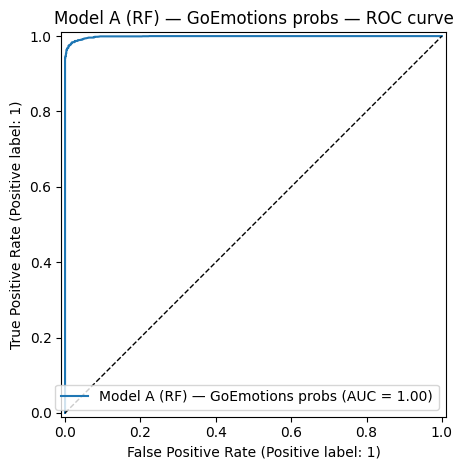

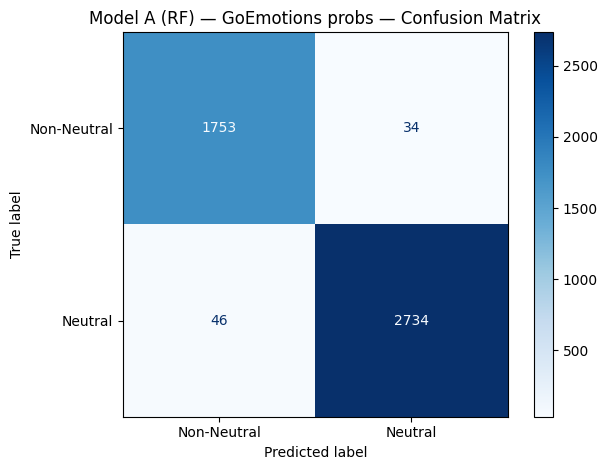


Top 15 Model A importances:
goe_neutral_prob        0.363005
goe_love_prob           0.107405
goe_curiosity_prob      0.057880
goe_grief_prob          0.053868
goe_remorse_prob        0.035244
goe_nervousness_prob    0.034532
goe_anger_prob          0.030977
goe_gratitude_prob      0.030173
goe_joy_prob            0.029302
goe_surprise_prob       0.025460
goe_fear_prob           0.025044
goe_admiration_prob     0.024940
goe_amusement_prob      0.019208
goe_sadness_prob        0.017232
goe_confusion_prob      0.015208


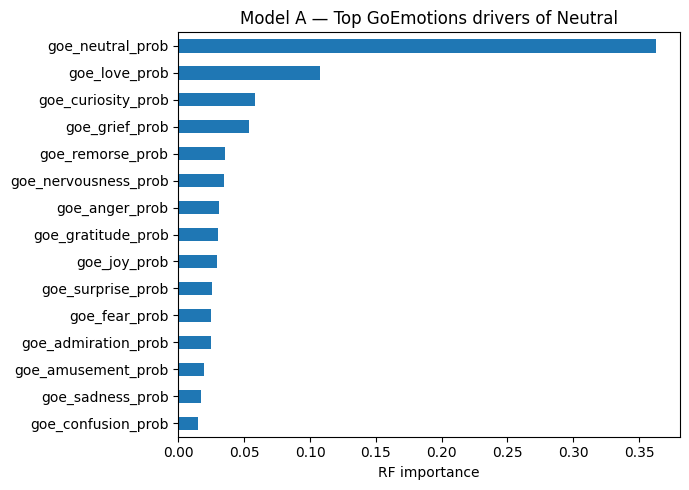


Model B (RF) — Explanation features
-----------------------------------
Accuracy : 0.7715
Precision: 0.7889
Recall   : 0.8526
F1-score : 0.8195
ROC-AUC  : 0.8414


<Figure size 600x500 with 0 Axes>

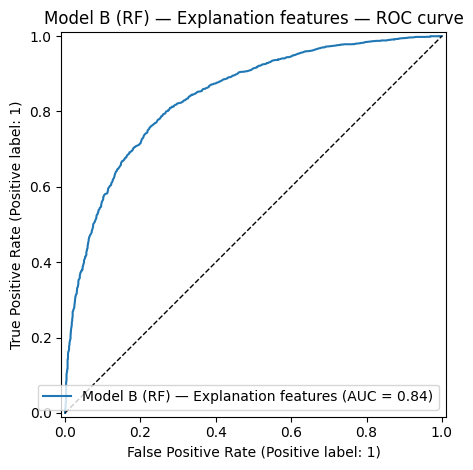

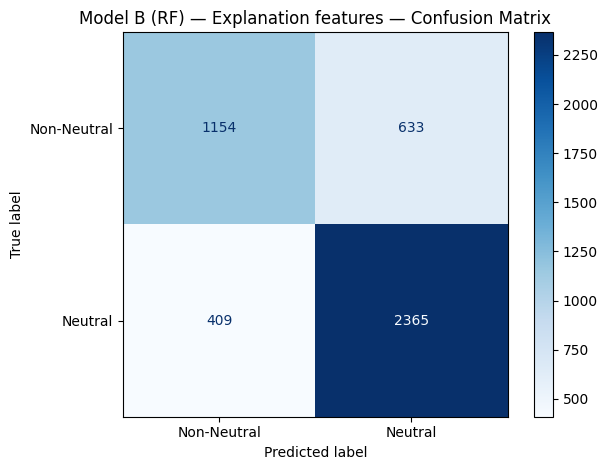


Top 20 Model B importances (what explains Neutral):
vader_neu                0.078747
vader_neg                0.072952
vader_compound           0.052252
va_val_std               0.044412
va_valence               0.043807
va_arousal               0.043031
va_aro_std               0.042747
tb_subjectivity          0.039836
num_comments_length      0.039731
va_body_cov              0.036730
tb_polarity              0.036603
vader_pos                0.034743
post_length              0.034209
va_body_hits             0.027134
post_year                0.026033
post_month               0.024734
num_comments             0.021502
keyword_anxiety          0.014877
severity_level_Normal    0.010036
severity_level_Low       0.008987


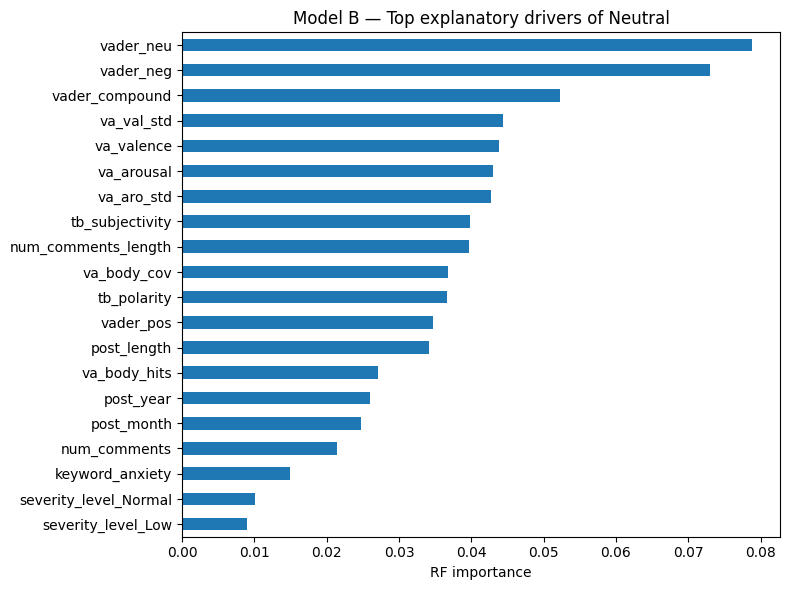


==================== SUMMARY ====================
Model A answers: 'Can neutral be predicted from GoEmotions probs?'
Model B answers: 'Which non-emotion signals explain neutral being high?'

Look at Model B top importances to write the story for your supervisor.


In [12]:
# ============================================================
# BeyondBlue Neutral Analysis — Two Random Forest Models
#   Model A: Prediction accuracy (GoEmotions 28 probs only)
#   Model B: Explanation (severity + VAD + length + time + keyword)
#
# Assumes df_beyondblue exists with columns you showed.
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support, roc_auc_score,
    confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay
)
from sklearn.ensemble import RandomForestClassifier
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

# -----------------------------
# 0) Load df
# -----------------------------
assert "df_beyondblue" in globals(), "df_beyondblue not found."
df = df_beyondblue.copy()

# -----------------------------
# 1) Target: is_neutral
# -----------------------------
df["is_neutral"] = (df["goe_ekman_dominant"].astype(str).str.lower() == "neutral").astype(int)

print("Target balance:")
print(df["is_neutral"].value_counts())

# ============================================================
# MODEL A — Prediction RF
# Features = all goe_*_prob EXCEPT ekman probs
# ============================================================

goe_prob_cols = [
    c for c in df.columns
    if c.startswith("goe_") and c.endswith("_prob") and ("ekman" not in c)
]

if len(goe_prob_cols) == 0:
    raise RuntimeError("No GoEmotions prob columns detected for Model A.")

df_A = df[goe_prob_cols + ["is_neutral"]].dropna()
X_A = df_A[goe_prob_cols]
y_A = df_A["is_neutral"]

X_A_train, X_A_test, y_A_train, y_A_test = train_test_split(
    X_A, y_A, test_size=0.25, random_state=42, stratify=y_A
)

rf_A = RandomForestClassifier(
    n_estimators=700,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)
rf_A.fit(X_A_train, y_A_train)

proba_A = rf_A.predict_proba(X_A_test)[:, 1]
pred_A  = (proba_A >= 0.5).astype(int)

# ---- Eval helper
def eval_and_plot(name, y_true, y_pred, y_proba):
    acc = accuracy_score(y_true, y_pred)
    prec, rec, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average="binary", zero_division=0
    )
    auc = roc_auc_score(y_true, y_proba)

    print(f"\n{name}")
    print("-" * len(name))
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall   : {rec:.4f}")
    print(f"F1-score : {f1:.4f}")
    print(f"ROC-AUC  : {auc:.4f}")

    # ROC
    plt.figure(figsize=(6,5))
    RocCurveDisplay.from_predictions(y_true, y_proba, name=name)
    plt.plot([0,1],[0,1],'k--',lw=1)
    plt.title(f"{name} — ROC curve")
    plt.tight_layout()
    plt.show()

    # Confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=["Non-Neutral", "Neutral"])
    disp.plot(values_format="d", cmap="Blues")
    plt.title(f"{name} — Confusion Matrix")
    plt.tight_layout()
    plt.show()

    return acc, prec, rec, f1, auc

scores_A = eval_and_plot("Model A (RF) — GoEmotions probs", y_A_test, pred_A, proba_A)

# ---- Feature importances (Model A)
imp_A = pd.Series(rf_A.feature_importances_, index=goe_prob_cols).sort_values(ascending=False)

print("\nTop 15 Model A importances:")
print(imp_A.head(15).to_string())

plt.figure(figsize=(7,5))
imp_A.head(15).sort_values().plot(kind="barh")
plt.title("Model A — Top GoEmotions drivers of Neutral")
plt.xlabel("RF importance")
plt.tight_layout()
plt.show()


# ============================================================
# MODEL B — Explanation RF
# Features = severity + VAD + length + time + keyword + quadrant
# (No GoEmotions/Ekman label leakage)
# ============================================================

explain_cols = [
    "severity_level",
    "vader_neg","vader_neu","vader_pos","vader_compound","vader_sentiment",
    "tb_polarity","tb_subjectivity","tb_sentiment",
    "otsu_class","jenks_class","gmm_class",
    "va_valence","va_arousal","va_val_std","va_aro_std",
    "va_title_hits","va_body_hits","va_title_cov","va_body_cov",
    "post_length","num_comments","num_comments_length",
    "post_month","post_year","year_month",
    "keyword","va_quadrant"
]

# keep only those that actually exist (safe)
explain_cols = [c for c in explain_cols if c in df.columns]

df_B = df[explain_cols + ["is_neutral"]].dropna()

X_B = df_B[explain_cols]
y_B = df_B["is_neutral"]

X_B_train, X_B_test, y_B_train, y_B_test = train_test_split(
    X_B, y_B, test_size=0.25, random_state=42, stratify=y_B
)

# Identify categorical vs numeric
cat_cols = [c for c in X_B.columns if X_B[c].dtype == "object"]
num_cols = [c for c in X_B.columns if c not in cat_cols]

preprocess = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
        ("num", "passthrough", num_cols)
    ]
)

rf_B = RandomForestClassifier(
    n_estimators=800,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1,
    max_depth=None
)

pipe_B = Pipeline([
    ("prep", preprocess),
    ("rf", rf_B)
])

pipe_B.fit(X_B_train, y_B_train)

proba_B = pipe_B.predict_proba(X_B_test)[:, 1]
pred_B  = (proba_B >= 0.5).astype(int)

scores_B = eval_and_plot("Model B (RF) — Explanation features", y_B_test, pred_B, proba_B)

# ---- Get feature names after one-hot
oh = pipe_B.named_steps["prep"].named_transformers_["cat"]
oh_names = []
if len(cat_cols) > 0:
    oh_names = oh.get_feature_names_out(cat_cols).tolist()

final_feature_names = oh_names + num_cols

imp_B = pd.Series(
    pipe_B.named_steps["rf"].feature_importances_,
    index=final_feature_names
).sort_values(ascending=False)

print("\nTop 20 Model B importances (what explains Neutral):")
print(imp_B.head(20).to_string())

plt.figure(figsize=(8,6))
imp_B.head(20).sort_values().plot(kind="barh")
plt.title("Model B — Top explanatory drivers of Neutral")
plt.xlabel("RF importance")
plt.tight_layout()
plt.show()

# ============================================================
# QUICK INTERPRETATION PRINTS
# ============================================================
print("\n==================== SUMMARY ====================")
print("Model A answers: 'Can neutral be predicted from GoEmotions probs?'")
print("Model B answers: 'Which non-emotion signals explain neutral being high?'")
print("\nLook at Model B top importances to write the story for your supervisor.")
print("=================================================")
